📝 Instrucciones

Sistema de clasificación de imágenes
El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.# Explore here

Paso 1: Carga del conjunto de datos
El conjunto de datos se encuentra en este link. Descarga la carpeta y descomprime los archivos. Ahora tendrás una carpeta con el dataset y una carpeta llamada train que contiene más de 25.000 archivos de imagen (formato .jpg) de perros y gatos. Las fotos están etiquetadas por su nombre de archivo, con la palabra dog o cat.

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import shutil
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
import zipfile
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

#descomprimir train en codespace
zip_path = "../data/raw/train.zip"
extract_path = "../data/raw"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir("../data/raw")[:10])

['train.zip', '.gitkeep', 'train']


In [28]:
#comprobar que si están las imágenes en trainn
raw_dir = "../data/raw/train"

print(os.listdir(raw_dir)[:10])
print("Total imágenes:", len(os.listdir(raw_dir)))

['dog.6653.jpg', 'cat.538.jpg', 'dog.9390.jpg', 'cat.1320.jpg', 'dog.783.jpg', 'cat.10001.jpg', 'cat.10168.jpg', 'dog.11034.jpg', 'dog.8833.jpg', 'cat.2128.jpg']
Total imágenes: 25000


Paso 2: Visualiza la información de entrada

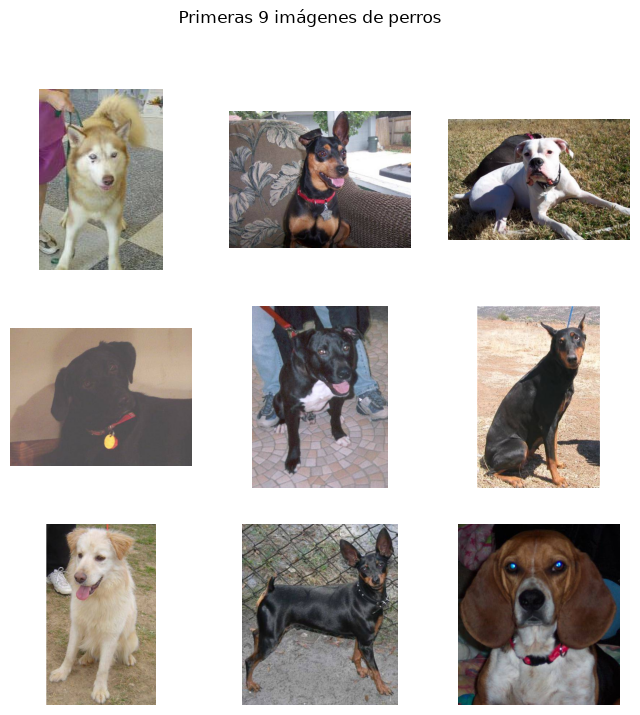

In [29]:
from PIL import Image
import matplotlib.pyplot as plt
import os

#carga e imprime las primeras nueve fotos de perros en una sola figura.
dog_images = [img for img in os.listdir(raw_dir) if img.startswith("dog")] #iterar para las archivos que nombrados comienen con dog

plt.figure(figsize=(8,8))
#iteración
for i, img_name in enumerate(dog_images[:9]):
    
    img = Image.open(os.path.join(raw_dir, img_name))
    #mostrar imagen
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Primeras 9 imágenes de perros")
plt.show()

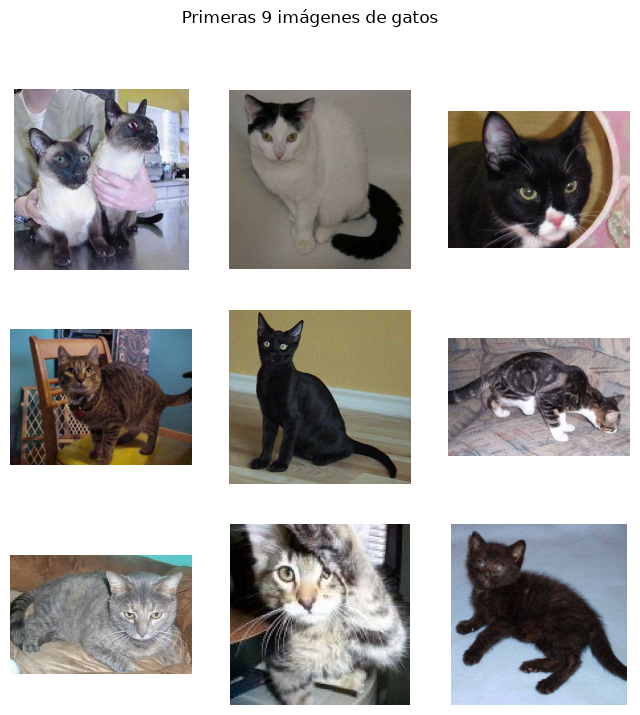

In [30]:
#9 fotos de los gatos

#escoger el lista que comienen con cat
cat_images = [img for img in os.listdir(raw_dir) if img.startswith("cat")]

plt.figure(figsize=(8,8))

for i, img_name in enumerate(cat_images[:9]):
    
    img = Image.open(os.path.join(raw_dir, img_name))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Primeras 9 imágenes de gatos")
plt.show()

Notas:
Las imágenes tienen diferente tamaño y colores.
Algunas muestran al animal mientras que otras muestran al animal y al humano que lo sostiene.



In [31]:
#Seleccionar la carpeta proccessed
processed_dir = "../data/processed"

#carpetas train y test
train_dir = os.path.join(processed_dir, "train")
test_dir = os.path.join(processed_dir, "test")

#crear las carpetas necesarias para Keras
#train/cats
#train/dogs
#test/cats
#test/dogs

for folder in [
    f"{train_dir}/cats", f"{train_dir}/dogs",
    f"{test_dir}/cats", f"{test_dir}/dogs"]:
    os.makedirs(folder, exist_ok=True) 
#definir la lisat e imagenes
images = [img for img in os.listdir(raw_dir) if img.endswith(".jpg")]


#dividir las imagenes
#80% para entrenamiento
#20% para prueba

train_imgs, test_imgs = train_test_split(
    images,
    test_size=0.2,
    random_state=42,
    stratify=[img.split(".")[0] for img in images])
#función para copiar las imágenes en su carpeta correspondiente
def copy_images(image_list, destination):
    for img in image_list:
           #extraer la etiqueta del nombre
        label = img.split(".")[0]
        class_folder = "cats" if label == "cat" else "dogs"
        #copiar imagen a la carpeta correspondiente
        shutil.copy(
            os.path.join(raw_dir, img),
            os.path.join(destination, class_folder, img)
        )

# Copiar imágenes de entrenamiento
copy_images(train_imgs, train_dir)
copy_images(test_imgs, test_dir)  #copiar las imágenes en la parte de prueba

In [32]:
#Cantidad de imágenes que hay en cada carrpeta 
print("Q Train cats:", len(os.listdir("../data/processed/train/cats")))
print("Q Train dogs:", len(os.listdir("../data/processed/train/dogs")))

print("Q Test cats:", len(os.listdir("../data/processed/test/cats")))
print("Q Test dogs:", len(os.listdir("../data/processed/test/dogs")))

Q Train cats: 10000
Q Train dogs: 10000
Q Test cats: 2500
Q Test dogs: 2500


In [33]:
#Crear los generadores de imágenes

#tamaño de imagen requerido por la arquitectura del modelo
img_size = (224, 224)

#número de imágenes que se procesan por lote
batch_size = 32

#generador para parte entrenamiento
#escale normaliza los píxeles de 0-255 a 0-1
train_datagen = ImageDataGenerator(rescale=1./255)

#generador para la parte e prrueba
test_datagen = ImageDataGenerator(rescale=1./255)

#Cargas las imágenes de entrenamiento
trdata = train_datagen.flow_from_directory(
    "../data/processed/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

#cargar imágenes de prueba
tsdata = test_datagen.flow_from_directory(
    "../data/processed/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


Paso 3: Construye una RNA

In [34]:
# Construcción del modelo CNN basado en arquitectura tipo VGG

model = Sequential()

# Bloque 1
model.add(Conv2D(input_shape=(224,224,3), filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 2
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 3
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 4
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 5
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Capas densas finales
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=2, activation="softmax"))

E0000 00:00:1781381234.928325   13634 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [35]:
#compilar modelo
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 134,268,738 (512.19 MB)

 Non-trainable params: 0 (0.00 B)